In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from google.colab import drive

#1.데이터셋 불러오기



In [ ]:
raw_df = pd.read_csv("/content/drive/MyDrive/owid-covid-data.csv")
raw_hi_df=pd.read_csv("/content/sample_data/hawaii-covid-data.csv")



/tmp/ipykernel_1413/2191304674.py:1: DtypeWarning: Columns (33) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_df = pd.read_csv("/content/drive/MyDrive/owid-covid-data.csv")


# 2. 필요한 열 가져오기

In [ ]:
f_raw_df=raw_df[["location","date","total_cases"]]
f_raw_hi_df=raw_hi_df[["submission_date","state",'tot_cases']]

# 3. 파이썬에서 인식가능한 날짜로 바꾸기

In [ ]:
f_raw_df["date2"] = pd.to_datetime(f_raw_df["date"])
f_raw_hi_df["date2"] = pd.to_datetime(f_raw_hi_df["submission_date"])


/tmp/ipykernel_1413/3046426814.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  f_raw_df["date2"] = pd.to_datetime(f_raw_df["date"])
/tmp/ipykernel_1413/3046426814.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  f_raw_hi_df["date2"] = pd.to_datetime(f_raw_hi_df["submission_date"])


# 4 한국 데이터 따오기

In [ ]:
korea = f_raw_df[f_raw_df.location == 'South Korea'].set_index("date2")["total_cases"].sort_index()
#== 한국에서 True인것만 가져오기 date2로 인덱스 나열맞추기 sortindex 날짜순으로 맞추기

# 5 하와이 데이터

In [ ]:
hi = f_raw_hi_df.set_index("date2")['tot_cases'].sort_index()

#6 데이터합치기

In [ ]:
comb_df = pd.DataFrame({"Kor":korea, "hawaii":hi})
#새로운 데이터 프레임 생성


# 7  그래프 그리기

<Axes: xlabel='date2'>

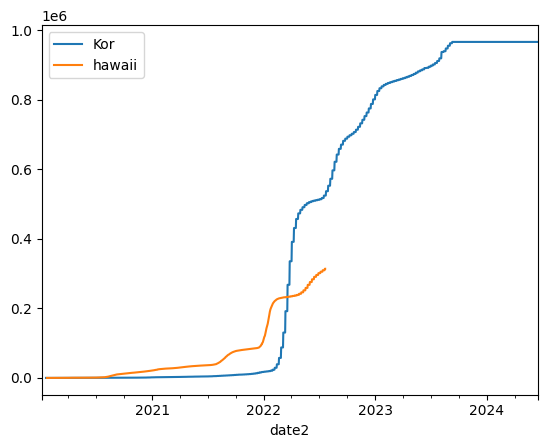

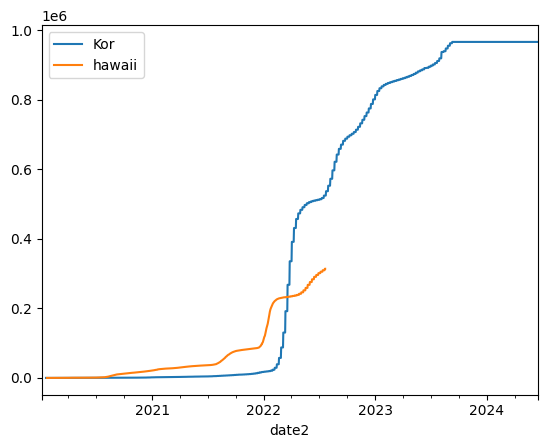

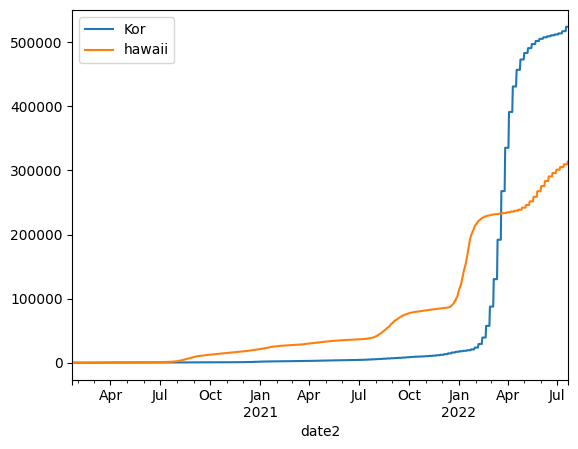

In [ ]:
lines = comb_df.plot.line()
ratio = 144.6/5175
comb_df = pd.DataFrame({"Kor":ratio*korea,"hawaii":hi})
lines = comb_df.plot.line()
comb_df['2020-01-22':'2022-07-21'].plot.line()
#비율 구하기 몇명당으로 맞춤